# DATASCI 185 — Cumulative Formula Sheet (Lectures 1–7)

Covers the old sheet (L3–L4, Assignment 2) plus **Lecture 5** (random, scipy, numpy arrays), **Lecture 6** (if/elif/else), **Lecture 7** (for/while loops, break/continue), **Assignment 3**, and the **practice quiz** (tuples, sets, `.index`).

**Jump to:** 0. Traps · 1. Imports · 2. Data · 3. Plots · 4. Variables & types · 5. Lists, tuples, sets · 6. Comparisons & logic · 7. Built-ins / math / numpy · 8. `random` · 9. `scipy.stats` · 10. if/elif/else · 11. Loops · 12. Practice quiz answers · 13. Assignment 3 answers · 14. Quick table

## 0. Top traps (read before the test)

| Trap | What happens | Fix |
|---|---|---|
| `x = x.append(7)` | `x` becomes `None` | just `x.append(7)` |
| `shuffled = random.shuffle(lst)` | `shuffled` is `None`; `lst` is shuffled in place | `random.shuffle(lst)` then use `lst` |
| `random.sample(lst, 1)` | returns a **list** `['Abed']`, not a string | `random.sample(lst, 1)[0]` or `random.choice(lst)` |
| `import statistics as stats` + `import scipy.stats as stats` | second import overwrites the first | `import statistics` (no alias), `import scipy.stats as stats` |
| `math.factorial` for big n | `OverflowError` | `stats.binom.pmf(k, n, p)` |
| `0.1*7 == 0.7` | `False` | `math.isclose(x, y)` / `abs(x-y) < 1e-13` |
| `while t != 1.0:` with float steps | infinite loop | `while abs(t - 1.0) > 1e-13:` |
| `random.randint(1, 6)` | **both** ends included | (unlike `range(1, 6)` → 1..5) |
| `range(N)` | 0 … N-1 | `range(1, N+1)` for 1 … N |
| list `+` vs array `+` | lists concatenate, arrays add element-wise | `np.array(...)` for math |
| `b = a` (lists) | same list, two names | `b = a.copy()` |
| `"10" + "2"` | `"102"` | `int("10") + int("2")` |
| `13 + 8 / 3` | 15.67 (division first) | `(13 + 8) / 3` |
| `x / 0` in numpy | `inf` (or `nan` for `0/0`) + warning, no crash | — |
| `my_tuple[0] = 5` | `TypeError` (tuples can't change) | convert/store in a list |
| `my_set.remove("X")` when X isn't there | `KeyError` | `if "X" in s: s.remove("X")` or `s.discard("X")` |
| `empty = {}` | that's a **dict**, not a set | `set()` |
| `my_set[0]` | `TypeError` (sets have no order/index) | use `in` |
| Q says use `binom` but describes negative binomial | wrong distribution | negative binomial = `stats.nbinom` |

## 1. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
import statistics            # no alias, so it doesn't clash with scipy.stats
import random
import scipy.stats as stats  # standard alias for scipy stats

Standard libraries (ship with Python, just `import`): `math`, `statistics`, `random`.
Third-party (must be installed; Anaconda pre-installs most): `numpy`, `pandas`, `matplotlib`, `scipy`.
`ModuleNotFoundError: No module named 'scipy'` → install it in your environment.

## 2. Reading data

```python
df = pd.read_csv("data/features.csv")        # path relative to the notebook
df["mpg"].describe()                         # count, mean, std, min, quartiles, max

cols = ["acceleration", "cylinders", "horsepower", "mpg"]
df[cols[3]].describe()                       # "don't type the column name" -> index a list

with open("quiz_data/majors.txt") as f:      # text file -> list of strings
    majors = [line.strip() for line in f]
```

## 3. Plotting

Pattern: plot → `xlabel` → `ylabel` → `title` → `plt.show()` (one `show()` per figure).

| Function | Use |
|---|---|
| `plt.scatter(x=..., y=...)` | points |
| `plt.plot(x, y)` | connected line (smooth curves, pdfs) |
| `plt.bar(x=..., height=..., color="hotpink")` | bars (pmfs, categories) |
| `plt.barh(labels, values)` | horizontal bars |

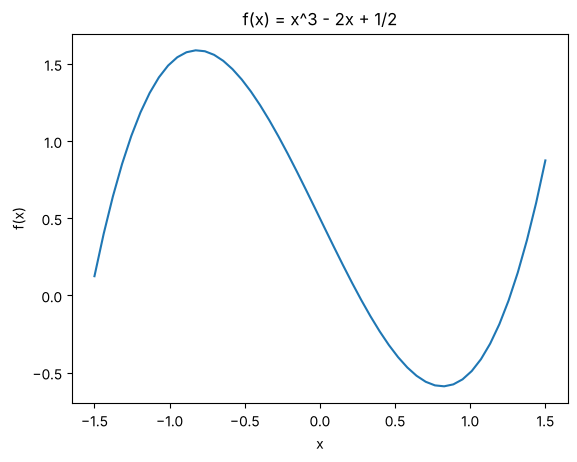

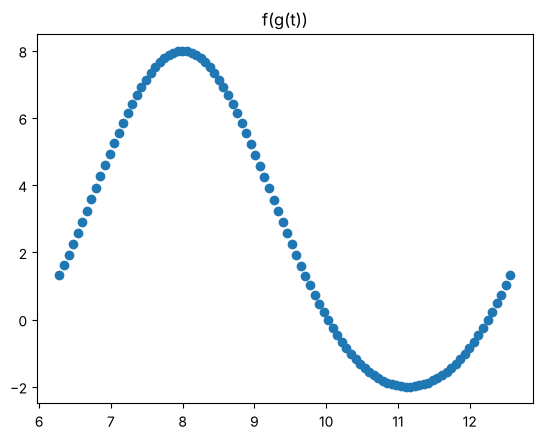

In [2]:
# Plot a function: numpy array of x values -> evaluate -> plot
x = np.linspace(-1.5, 1.5, 50)          # 50 evenly spaced points, endpoints included
y = x**3 - 2*x + 0.5
plt.plot(x, y)
plt.xlabel("x"); plt.ylabel("f(x)"); plt.title("f(x) = x^3 - 2x + 1/2")
plt.show()

# Composition f(g(t)): compute the inner one first
t = np.linspace(2*np.pi, 4*np.pi, 100)
g = np.sin(t + 3)
f_of_g = g**2 - 5*g + 2
plt.scatter(x=t, y=f_of_g)
plt.title("f(g(t))"); plt.show()

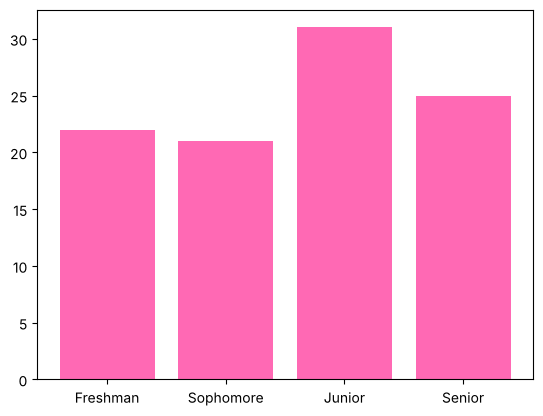

In [3]:
# Conditional color (Lecture 6 exercise)
categories = ["Freshman", "Sophomore", "Junior", "Senior"]
count = [22, 21, 31, 25]
is_pink = True
if is_pink:
    plt.bar(x=categories, height=count, color="hotpink")
else:
    plt.bar(x=categories, height=count)
plt.show()

Several plots with a loop (Lecture 7 ex. 4):
```python
carfeatures = pd.read_csv("data/features.csv")
for col in ["displacement", "weight", "acceleration"]:
    plt.scatter(x=carfeatures[col], y=carfeatures["mpg"])
    plt.xlabel(col); plt.ylabel("mpg"); plt.title(f"{col} vs. mpg")
    plt.show()
```
Bar x-values that are **strings** plot in given order; **numbers** plot in numeric order.

## 4. Variables, types, strings

In [4]:
a, b = "left", "right"
a, b = b, a                      # swap (b = a; a = b does NOT swap)

print("10" + "2", int("10") + int("2"), str(12))   # 102  12  '12'
print(type(True), type("True"))                    # bool vs str

name = "Jeff"
print("Hi " + name + "!")                # concatenation: add your own spaces
print(f"Hi {name}, {len(name)} letters") # f-string: needs the f AND the {}
print("Total:", 3 + 4)                   # print with commas adds spaces automatically

102 12 12
<class 'bool'> <class 'str'>
Hi Jeff!
Hi Jeff, 4 letters
Total: 7


## 5. Lists

In [5]:
colors = ["red", "green", "yellow", "indigo"]
colors[0], colors[-1], colors[len(colors)-1]       # first, last, last

birthdays = [["Abed", "March", 23, 2007], ["Jeff", "December", 8, 1990]]  # list of lists
birthdays[1][0]          # 'Jeff'  -> [row][field]
len(birthdays), len(birthdays[0])                  # 2 people, 4 fields each
birthdays[0][2] = 1      # changes the original list (assignment by index)

combined = [1, 2] + [3]  # concatenate -> [1, 2, 3]
grow = []
grow = grow + [5]        # add by concatenation (needs reassignment)
grow.append(7)           # add in place (NO reassignment, returns None)
print(grow)              # [5, 7]

[5, 7]


In [6]:
nums = [5.3, 25, -0.1, -5]
nums.sort()        # in place, ascending
nums.reverse()     # in place
nums.count(25)     # occurrences -> 1
copy = nums.copy() # independent copy
list(range(1, 11, 2))   # [1, 3, 5, 7, 9]  (start, stop-exclusive, step)

[1, 3, 5, 7, 9]

### Tuples `( )` and sets `{ }`

| | List `[ ]` | Tuple `( )` | Set `{ }` |
|---|---|---|---|
| Ordered / indexable | yes | yes | **no** |
| Changeable | yes | **no** | yes (add/remove) |
| Duplicates | allowed | allowed | **removed** |
| Key methods | `.append .sort .index .count` | `.index .count` | `.add .remove .discard` |

In [7]:
names = ("Mexico", "Taiwan", "Greece")      # tuple
pops  = [135.674, 23.243, 10.432]           # list in the SAME order
i = names.index("Greece")                   # position of first match -> 2 (ValueError if missing)
print(names[i], pops[i])                    # use one index across parallel sequences
pops[i] = 9.267                             # OK: list.  names[i] = "X" would be a TypeError

courses = {"DATASCI 185", "MATH 250"}       # set
courses.add("BIOL 301")                     # add one item
courses.discard("MATH 999")                 # remove if present, silent otherwise
if "MATH 250" in courses:                   # remove() errors if missing, so check first
    courses.remove("MATH 250")
print(courses, set([1, 1, 2]))              # {1, 2}: duplicates dropped

Greece 10.432
{'DATASCI 185', 'BIOL 301'} {1, 2}


## 6. Comparisons, logic, membership

`>  <  >=  <=  ==  !=` · `=` assigns, `==` compares · chained: `10 < price <= 20`
Strings compare **alphabetically** (uppercase sorts before lowercase: `"Z" < "a"` is True).
Lists compare **element by element, stopping at the first difference**: `[0,0,0,0,0] <= [5,50,75,100,-0.01]` is `True` because `0 < 5` decides it.
`and` both · `or` at least one · `^` exactly one · `not` flips
`in` checks membership (case-sensitive): `"Monday" in free_days`, `"eco" in "economic"`

In [8]:
a, b, c = 3, 4, 5
print(a**2 + b**2 == c**2)          # right-triangle test -> True
print("Abed" < "Britta")            # True (alphabetical)
x, y = 0.1*7, 0.7
print(x == y, math.isclose(x, y), abs(x - y) < 1e-13)   # False True True

True
True
False True True


## 7. Built-ins, `math`, `statistics`, `numpy`

In [9]:
print(type(3.14), abs(-10), len([2, 3, 4]), round(3.1415), round(3.1415, 2))
print(math.sqrt(25), math.factorial(5), math.pi)          # single values only
print(statistics.mean([1, 2, 3]), statistics.median([1, 2, 3]), statistics.stdev([1, 2, 3]))

<class 'float'> 10 3 3 3.14
5.0 120 3.141592653589793
2 2 1.0


In [10]:
# Arrays: math is element-by-element (lists would concatenate)
a = np.array([2, 1.2, 3.4])
b = np.array([2.2, -3, 10.01])
c = a * b            # [a1*b1, a2*b2, a3*b3]
d = 5 - a            # scalar with array
e = (a - b) / 2
f = b ** a           # [b1^a1, ...]
g = 2 ** a
h = np.exp(a + b)

np.log(2), np.exp(2), np.sin(2), np.cos(2), np.sqrt(2)   # log = natural log (ln)
np.pi, np.e
np.ones(5) * 13          # array([13., 13., 13., 13., 13.])
np.linspace(-5, 5, 100)  # 100 evenly spaced points from -5 to 5
np.sum(a), np.mean(a), np.cumsum(a), np.argmax(a), np.min(a)   # argmax = INDEX

/tmp/ipykernel_182/259720102.py:7: RuntimeWarning: invalid value encountered in power
  f = b ** a           # [b1^a1, ...]


(np.float64(6.6),
 np.float64(2.1999999999999997),
 array([2. , 3.2, 6.6]),
 np.int64(2),
 np.float64(1.2))

In [11]:
x = 0.5
print(np.pi * x**2)
print(1/np.sqrt(2*np.pi) * np.exp(-x**2))
print(np.log((2*x + 1) / (x + 2)))       # parentheses around numerator AND denominator
print(27 / (12 - 3), (5 + 3) * 2, 5*3 + 2*4, (5 + 3) * 2 / 4)   # 3.0 16 23 4.0

with np.errstate(divide="ignore", invalid="ignore"):
    print(np.array([0, 1.0, np.pi, 1]) / np.array([0, 2.0, 4, 0]))  # [nan 0.5 0.785 inf]

0.7853981633974483
0.3106965603769278
-0.2231435513142097
3.0 16 23 4.0
[       nan 0.5        0.78539816        inf]


## 8. `random` library (standard)

| Function | Returns | Replacement? |
|---|---|---|
| `random.choice(lst)` | 1 item | — |
| `random.choices(lst, k=5)` | list of 5 | **with** (repeats possible) |
| `random.sample(lst, k=5)` | list of 5 | **without** (no repeats) |
| `random.shuffle(lst)` | `None` (shuffles `lst` in place) | — |
| `random.randint(a, b)` | int, **a and b included** | with |
| `random.seed(673012485234)` | makes results repeatable | — |

In [12]:
days = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]
free_days = ["Monday", "Thursday", "Friday"]
random.seed(67)
proposed_day = random.choice(days)
is_free = proposed_day in free_days
print(proposed_day, is_free)

roll = random.randint(1, 6)                     # one die roll
idx = random.randint(0, len(days) - 1)          # random valid index (note the -1)
# numpy version: np.random.seed(...); np.random.randint(0, 365, (5, 5)); np.random.uniform(low, high, size)

Sunday False


## 9. `scipy.stats` distributions

| Distribution | Meaning | Code |
|---|---|---|
| Binomial | P(k heads in n flips) $=\frac{n!}{k!(n-k)!}p^k(1-p)^{n-k}$ | `stats.binom.pmf(k, n, p)` |
| Negative binomial | P(k tails before the n-th head) $=\frac{(k+n-1)!}{k!(n-1)!}p^n(1-p)^k$ | `stats.nbinom.pmf(k, n, p)` |
| Normal | density at x | `stats.norm.pdf(x, loc=mean, scale=sd)` (default 0, 1) |

**Discrete** (binom, nbinom) → **pmf** → plot with `plt.bar`. **Continuous** (norm) → **pdf** → plot with `plt.plot`.
`k` can be a single number or a whole list/array (returns an array).

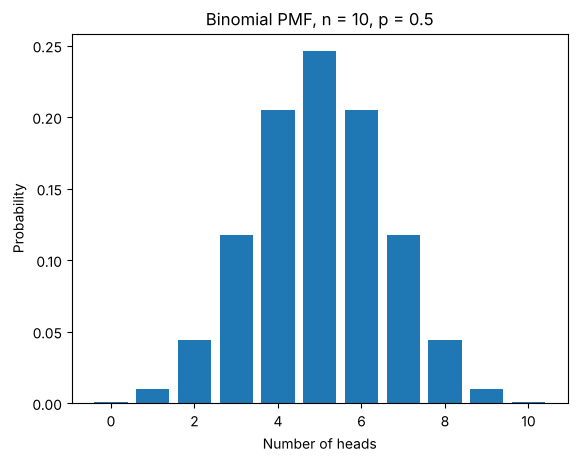

0.025225018178360804


In [13]:
# Binomial pmf (Lecture 5)
n, p = 10, 0.5
k = list(range(0, 11))                     # [0, 1, ..., 10]
plt.bar(k, stats.binom.pmf(k, n, p))
plt.title(f"Binomial PMF, n = {n}, p = {p}"); plt.xlabel("Number of heads"); plt.ylabel("Probability")
plt.show()
print(stats.binom.pmf(500, 1000, 0.5))     # works where math.factorial overflows

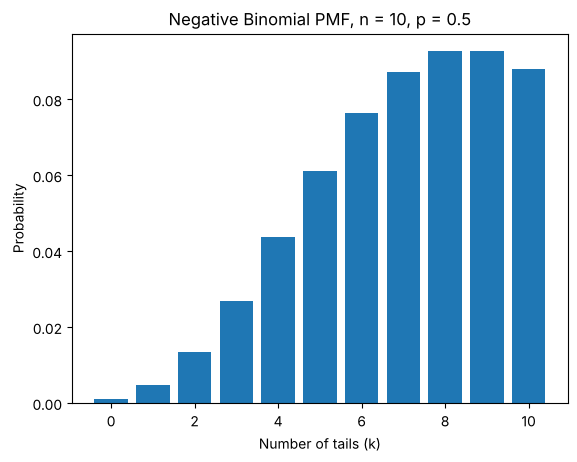

In [14]:
# Negative binomial pmf: k tails before n = 10 heads, fair coin
n, p = 10, 0.5
k = np.arange(0, 11)                       # same as list(range(0, 11))
plt.bar(k, stats.nbinom.pmf(k, n, p))
plt.title("Negative Binomial PMF, n = 10, p = 0.5"); plt.xlabel("Number of tails (k)"); plt.ylabel("Probability")
plt.show()

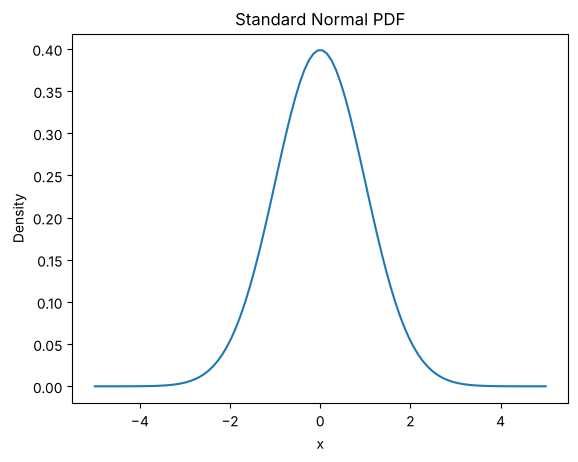

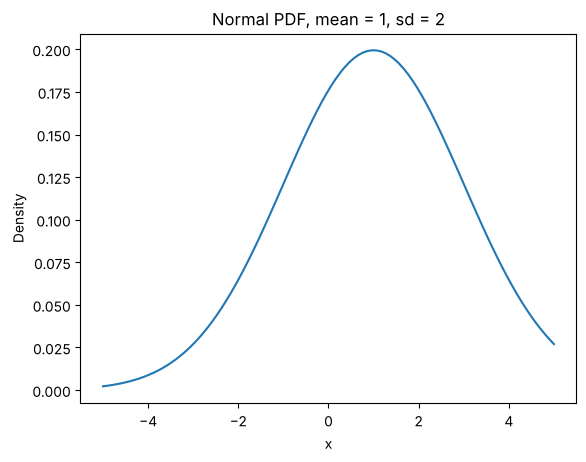

In [15]:
# Normal pdfs (Assignment 3c) -- two SEPARATE plots
x = np.linspace(-5, 5, 100)

plt.plot(x, stats.norm.pdf(x))
plt.title("Standard Normal PDF"); plt.xlabel("x"); plt.ylabel("Density")
plt.show()

plt.plot(x, stats.norm.pdf(x, loc=1, scale=2))
plt.title("Normal PDF, mean = 1, sd = 2"); plt.xlabel("x"); plt.ylabel("Density")
plt.show()

## 10. Conditionals (if / elif / else)

```python
if cond1:          # colon + indented body
    ...
elif cond2:        # checked only if cond1 was False
    ...
else:              # runs if nothing above was True (optional: leave it out to do nothing)
    ...
```
Only the **first** True branch runs. Separate `if`s are each checked independently.

In [16]:
# Range buckets (Lecture 6 ex. 4)
n = random.randint(1, 20)
if 1 <= n < 5:
    print(n, "is in [1, 5)")
elif 5 <= n <= 10:
    print(n, "is in [5, 10]")
elif 10 < n < 15:
    print(n, "is in (10, 15)")
else:
    print(n, "is >= 15")          # ex. 5: delete the else to do nothing

# Sum threshold
c = np.array([1, 2, 3])
print("The sum is greater than or equal to 5" if np.sum(c) >= 5 else "It is strictly less than 5")

14 is in (10, 15)
The sum is greater than or equal to 5


In [17]:
# Season with `in` + if/elif/else
birthdays = [["Abed", "March", 23, 2007], ["Britta", "July", 14, 1998], ["Jeff", "December", 8, 1990],
             ["Shirley", "January", 19, 1990], ["Annie", "September", 27, 2007], ["Pierce", "December", 30, 1962]]
person = random.choice(birthdays)
month = person[1]
if month in ["December", "January", "February"]:
    season = "Winter"
elif month in ["March", "April", "May"]:
    season = "Spring"
elif month in ["June", "July", "August"]:
    season = "Summer"
else:
    season = "Fall"
print(f"{person[0]} was born in {month}, which is in {season}.")

# "Lie about age": only replace if born before 2000
day, year = person[2], person[3]
if year < 2000:
    month = random.choice(["January", "February", "March", "April", "May", "June", "July",
                           "August", "September", "October", "November", "December"])
    day = random.randint(1, 30)
    year = random.randint(2000, 2004)
print(f"{person[0]} says they were born {month} {day} {year}.")
# This does NOT change `birthdays`. To change it: person[1] = month (person points to the same inner list)

Shirley was born in January, which is in Winter.
Shirley says they were born July 9 2004.


## 11. Loops

```python
for item in my_list:        # item takes each value in turn
for i in range(len(lst)):   # i = 0, 1, ..., len-1  -> use lst[i]
while condition:            # repeats until condition is False; MUST change something inside
break                       # exit the loop entirely
continue                    # skip the rest of THIS pass, go to next item
```
`range(N)` → 0..N-1 · `range(a, b)` → a..b-1 · `range(a, b, step)` · `list(range(...))` to preview.
**Unrolling** a loop = writing each pass out by hand (exam may ask you to do this or predict output).

In [18]:
# Two lists in parallel (filter movies)
titles = ["The Good, the Bad, the Weird", "Citizen Kane", "Spider-Man: Across the Spider-Verse"]
ratings = [7.2, 8.2, 8.5]
good, ok, bad = [], [], []
for i in range(len(titles)):
    if ratings[i] >= 8.0:
        good.append(titles[i])
    elif ratings[i] >= 6.0:
        ok.append(titles[i])
    else:
        bad.append(titles[i])
        print("Warning! Bad movie alert:", titles[i])
print(good, ok, bad)

# Manual index counter (same result)
index = 0
for car in ["KIA", "Ferrari", "Ford"]:
    print(f"Dear {car} customer, your position is {index + 1}")
    index = index + 1

['Citizen Kane', 'Spider-Man: Across the Spider-Verse'] ['The Good, the Bad, the Weird'] []
Dear KIA customer, your position is 1
Dear Ferrari customer, your position is 2
Dear Ford customer, your position is 3


In [19]:
# Accumulators
n = 31
S = 0
for k in range(1, n + 1):          # 1 + 2 + ... + n
    S = S + k
print(S, n*(n+1)//2)               # check: 496 496

arr = np.random.uniform(low=-5, high=10, size=25)
pos_sum = 0
for v in arr:                      # sum positives with continue
    if v <= 0:
        continue
    pos_sum = pos_sum + v
print(pos_sum, np.sum(arr[arr > 0]))

496 496
73.58445234840963 73.58445234840963


In [20]:
# continue vs break with mixed types, printing the POSITION of bad items
list_mixed = [1, 2, None, 4, "missing", 11, 2.2, None, "missing", 3]
total = 0
for i in range(len(list_mixed)):
    value = list_mixed[i]
    if (type(value) != int) and (type(value) != float):
        print("Non-numerical element at index", i)
        continue                   # use break here to STOP at the first bad item
    total = total + value
print(total)                       # 23.2

Non-numerical element at index 2
Non-numerical element at index 4
Non-numerical element at index 7
Non-numerical element at index 8
23.2


In [21]:
# while: unknown number of repeats -- rolls until a 6
rolls = 0
is_six = False
while not is_six:
    roll = random.choice([1, 2, 3, 4, 5, 6])
    rolls = rolls + 1
    if roll == 6:
        is_six = True
print("Took", rolls, "rolls")

# while with a threshold
eps, x = 0.025, 1
x_list, y_list = [], []
while 1/x > eps:
    x_list.append(x); y_list.append(1/x)
    x = x + 1                      # forget this line -> infinite loop

# find first two "tennis" indexes
sports = ["tennis", "golf", "basketball", "tennis", "golf"]
found, i = [], 0
while len(found) < 2:
    if sports[i] == "tennis":
        found.append(i)
    i = i + 1
print(found)                       # [0, 3]

# float time steps: never use != with floats
t, final_time, dt, successes = 0.0, 1.0, 0.1, 0
while abs(t - final_time) > 1e-13:
    if random.choice(["Success", "Failure"]) == "Success":
        successes = successes + 1
    t = t + dt
print(successes)

Took 6 rolls
[0, 3]
7


In [22]:
# for + break instead of while: Euler's pi^2/6 series, stop when term < tol
tol = 1e-6
total = 0
for k in range(1, 10_000_000):     # big upper limit acts as a safety cap
    term = 1 / k**2
    if term < tol:
        break
    total = total + term
print(total, np.pi**2 / 6)

1.6439345666815615 1.6449340668482264


## 12. Practice quiz — worked answers (real test is usually very similar)

In [23]:
# (A) 7 DIFFERENT cards, repeatable -> random.sample + seed reset before each draw
deck = ["A", "2", "3", "4", "5", "6", "7", "8", "9", "10", "J", "Q", "K"]
random.seed(1337)
hand = random.sample(deck, k=7)
print(hand)
random.seed(1337)
hand = random.sample(deck, k=7)
print(hand)                                  # identical to the first

['10', '9', '6', 'K', '3', 'J', '4']
['10', '9', '6', 'K', '3', 'J', '4']


In [24]:
# (B) Nested if/elif -- no `and` needed: check the scale first, then go up the thresholds in order
temperature = random.randint(0, 110)
temp_scale = random.choice(["Fahrenheit", "Celsius"])

if temp_scale == "Fahrenheit":
    if temperature < 60:
        feels = "cold"
    elif temperature <= 80:
        feels = "just right"
    else:
        feels = "hot"
else:
    if temperature < 15:
        feels = "cold"
    elif temperature <= 26:
        feels = "just right"
    elif temperature <= 48:                  # earlier branches already ruled out <= 26
        feels = "hot"
    else:
        feels = "like I am dying"
print(temperature, temp_scale, f"It feels {feels}")

81 Celsius It feels like I am dying


In [25]:
# (C) Running sum with break; track the index of the last receipt counted (numbered from 0)
receipts = np.random.uniform(size=10) * 30
receipt_number = -1                          # becomes 0 on the first pass
my_sum = 0
for value in receipts:
    receipt_number = receipt_number + 1
    my_sum = my_sum + value
    if my_sum > 90:
        break
print(f"stopped at receipt # {receipt_number}")
# equivalent: for receipt_number in range(len(receipts)): my_sum += receipts[receipt_number]; if my_sum > 90: break

stopped at receipt # 4


In [26]:
# (D) while loop: rolls until the SECOND 3 -> two counters (rolls and threes)
num_rolls = 0
num_threes = 0
while num_threes < 2:
    roll = random.choice([1, 2, 3, 4, 5, 6])
    num_rolls = num_rolls + 1                # count EVERY roll
    if roll == 3:
        num_threes = num_threes + 1
print("Number of rolls:", num_rolls)
# Variations: "until a 6" -> stop when count reaches 1; "until two 3s IN A ROW" -> reset num_threes = 0 on non-3

Number of rolls: 6


In [27]:
# (E) .index on a tuple, then use that index everywhere
formal_names = ("United Mexican States", "Republic of China", "Hellenic Republic")
informal_names = ("Mexico", "Taiwan", "Greece")
pop_estimate = [135.674, 23.243, 10.432]

change_index = formal_names.index("Hellenic Republic")
name = informal_names[change_index]
print(f"Old population estimate of {name} is {pop_estimate[change_index]} million")
pop_estimate[change_index] = 9.267
print(f"Current population estimate of {name} is {pop_estimate[change_index]} million")

Old population estimate of Greece is 10.432 million
Current population estimate of Greece is 9.267 million


In [28]:
# (F) Sets: add, then remove only if present (no KeyError)
course_schedule = {"DATASCI 325", "DATASCI 210", "MATH 346", "BIOL 223"}
course_schedule.add("BIOL 301")
for course in ["MATH 250", "DATASCI 325", "MATH 346"]:
    if course in course_schedule:
        course_schedule.remove(course)       # or just: course_schedule.discard(course)
print(course_schedule)

{'DATASCI 210', 'BIOL 223', 'BIOL 301'}


## 13. Assignment 3 — worked answers

In [29]:
# (a) [56, 23, 454, 1] -> [5, 56, 23, 454, 1, 4] using only len, append, reverse
q2_list = [56, 23, 454, 1]
q2_list.append(len(q2_list))   # [56, 23, 454, 1, 4]
q2_list.reverse()              # [4, 1, 454, 23, 56]
q2_list.append(len(q2_list))   # [4, 1, 454, 23, 56, 5]
q2_list.reverse()              # [5, 56, 23, 454, 1, 4]
print(q2_list)

[5, 56, 23, 454, 1, 4]


**(b)** The question says `binom`, but "tails before the n-th head" is the **negative binomial** → use `stats.nbinom.pmf(k, 10, 0.5)` (see section 9). **(c)** Normal pdfs: section 9.

In [30]:
# (d) alphabetical order -- random.sample returns a LIST, so take [0]
string_list = ["Frankie", "Nathan", "Peter", "Abed", "Britta", "Elroy"]
name1 = random.sample(string_list, 1)[0]
name2 = random.sample(string_list, 1)[0]

if name1 < name2:
    print(f"{name1} comes before {name2}")
elif name2 < name1:
    print(f"{name2} comes before {name1}")
else:                                   # neither is smaller -> same (no == needed)
    print("The names are the same")

# Other no-== options: `if name1 != name2: ... else: same`, or `not (name1 < name2 or name2 < name1)`

Abed comes before Frankie


## 14. Quick-scan table

| Task | Syntax |
|---|---|
| Read CSV / stats | `pd.read_csv("data/f.csv")`, `df["col"].describe()` |
| Scatter / line / bar | `plt.scatter(x=, y=)`, `plt.plot(x, y)`, `plt.bar(x=, height=, color=)` |
| Labels | `plt.xlabel()`, `plt.ylabel()`, `plt.title()`, `plt.show()` |
| Evenly spaced points | `np.linspace(start, stop, num)` |
| Element-wise math | `np.array(lst)` then `+ - * / **`, `np.exp`, `np.log`, `np.sqrt`, `np.sin` |
| Constants | `np.pi`, `np.e` |
| Swap | `a, b = b, a` |
| Add to list | `lst.append(x)` (no `=`) or `lst = lst + [x]` |
| Copy list | `lst.copy()` |
| Nested index | `lst[row][col]` |
| Find position | `seq.index(value)` (list or tuple) |
| Set add / safe remove | `s.add(x)`, `s.discard(x)` or `if x in s: s.remove(x)` |
| Empty set | `set()` (not `{}`) |
| Random 1 / k with / k without | `random.choice`, `random.choices(k=)`, `random.sample(k=)` |
| Random int incl. both ends | `random.randint(a, b)` |
| Repeatable | `random.seed(big_int)` |
| Binomial / neg. binomial pmf | `stats.binom.pmf(k, n, p)`, `stats.nbinom.pmf(k, n, p)` |
| Normal pdf | `stats.norm.pdf(x, loc=mu, scale=sd)` |
| Factorial | `math.factorial(n)` |
| Membership | `x in lst` |
| Float compare | `math.isclose(x, y)` |
| Loop over items / indexes | `for v in lst:` / `for i in range(len(lst)):` |
| Repeat until | `while cond:` (update something inside!) |
| Exit / skip | `break` / `continue` |
| Running total | `total = 0` before loop, `total = total + v` inside |
| Count until N hits | `while hits < N:` roll, `rolls += 1`, `if roll == target: hits += 1` |
| Last index counted before break | start `idx = -1`, `idx += 1` at top of loop |